# Combined melting-point dataset analysis

This notebook is the general analysis workspace for the curated melting-point data. It currently covers:

- an overview of the saved combined dataset and multiple-MP audit;
- source-level melting-point distributions and low/high composition;
- structural overlap across the four input datasets;
- pairwise melting-point agreement for shared canonical structures.

Run `combine_data_process.ipynb` first whenever the input files change so that `outputs/combined_data.parquet` and `outputs/multiple_MP_compounds.csv` are synchronized.

For source-level comparisons, this notebook independently applies the same SMILES parsing, canonical isomeric SMILES conversion, metal exclusion, single-component requirement, halogen retention, and strict `MW < 1000` criterion as the combination workflow. Each canonical compound counts once per source; when one source contains multiple MP observations for a structure, their within-source median is used for this EDA. Source-level medians are then restricted to 0–500 °C.

**PATENTS clarification:** strict numeric intervals are converted to their midpoint during extraction. Later statistics are calculated from processed observations across records or sources; they are not extracted from the PATENTS interval.

In [1]:
from pathlib import Path
import re
from itertools import combinations

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, StrMethodFormatter
from IPython.display import display
from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors

RDLogger.DisableLog('rdApp.*')

data_dir_candidates = [Path.cwd(), Path.cwd() / '0_data', Path.cwd().parent / '0_data']
DATA_DIR = next((path.resolve() for path in data_dir_candidates
                 if (path / 'input_datasets').is_dir() and (path / 'outputs').is_dir()), None)
if DATA_DIR is None:
    raise FileNotFoundError(
        'Could not locate 0_data/input_datasets and 0_data/outputs. Run this notebook '
        'from the repository root or from the 0_data directory.'
    )

INPUT_DIR = DATA_DIR / 'input_datasets'
OUTPUT_DIR = DATA_DIR / 'outputs'
COMBINED_DATA_PATH = OUTPUT_DIR / 'combined_data.parquet'
MULTIPLE_MP_PATH = OUTPUT_DIR / 'multiple_MP_compounds.csv'

NAMES = {1: '1 — ChemXplore', 2: '2 — EGNN', 3: '3 — PATENTS', 4: '4 — Bradley'}
ORDER = list(NAMES)
COLORS = {1: '#3567A8', 2: '#3A9D7D', 3: '#D18A32', 4: '#8A5DA8'}
CLASS_COLORS = {'Low (<250 °C)': '#4C78A8', 'High (≥250 °C)': '#E45756'}
MP_MIN, MP_MAX, HIGH_THRESHOLD, MAX_MW = 0.0, 500.0, 250.0, 1000.0

SPECS = [
    (1, '1_ChemXplore_tmpC_Marimuthu_2025.csv', 'tmp/ºC', 'chemxplore'),
    (2, '2_EGNN_mp_Huang_2025.csv', 'Melt_C', 'numeric'),
    (3, '3_PATENTS_ochem_Tetko_2016.parquet',
     'Melting Point {measured, converted}', 'numeric_or_range'),
    (4, '4_Bradley_Austermeier_2025.csv', 'MP', 'numeric'),
]

required_paths = [COMBINED_DATA_PATH, MULTIPLE_MP_PATH] + [
    INPUT_DIR / filename for _, filename, _, _ in SPECS
]
missing_paths = [str(path) for path in required_paths if not path.is_file()]
if missing_paths:
    raise FileNotFoundError(f'Missing required file(s): {missing_paths}')

schema_rows = []
for source, filename, mp_column, _ in SPECS:
    path = INPUT_DIR / filename
    columns = (pq.read_schema(path).names if path.suffix.lower() == '.parquet'
               else pd.read_csv(path, nrows=0).columns.tolist())
    missing_columns = sorted({'SMILES', mp_column}.difference(columns))
    if missing_columns:
        raise ValueError(f'{filename} is missing required column(s): {missing_columns}')
    schema_rows.append({
        'Source': source, 'Source_name': NAMES[source], 'Filename': filename,
        'SMILES_column': 'SMILES', 'MP_column': mp_column,
    })

plt.style.use('seaborn-v0_8-whitegrid')
print(f'Data directory: {DATA_DIR}')
display(pd.DataFrame(schema_rows))

Data directory: /Users/sdl5_mp/Documents/GitHub/melting_point_2026/0_data


,Source,Source_name,Filename,SMILES_column,MP_column
0,1,1 — ChemXplore,1_ChemXplore_tmpC_Marimuthu_2025.csv,SMILES,tmp/ºC
1,2,2 — EGNN,2_EGNN_mp_Huang_2025.csv,SMILES,Melt_C
2,3,3 — PATENTS,3_PATENTS_ochem_Tetko_2016.parquet,SMILES,"Melting Point {measured, converted}"
3,4,4 — Bradley,4_Bradley_Austermeier_2025.csv,SMILES,MP


## Final combined dataset overview

This section reads the saved curated outputs. It does not rebuild or modify them. High MP is defined as **≥250 °C**.

In [2]:
combined_data = pd.read_parquet(COMBINED_DATA_PATH)
multiple_mp_audit = pd.read_csv(MULTIPLE_MP_PATH)

required_combined_columns = {
    'SMILES', 'MP', 'Source', 'MP_quality', 'Consensus_method',
    'ContainsHalogen', 'MW',
}
missing_combined_columns = sorted(required_combined_columns.difference(combined_data.columns))
if missing_combined_columns:
    raise ValueError(f'combined_data.parquet is missing columns: {missing_combined_columns}')

combined_class = np.where(
    combined_data['MP'].ge(HIGH_THRESHOLD), 'High (≥250 °C)', 'Low (<250 °C)'
)
overview = pd.DataFrame({
    'Metric': [
        'Final compounds', 'Low-MP compounds', 'High-MP compounds',
        'Minimum MP (°C)', 'Median MP (°C)', 'Maximum MP (°C)',
        'Minimum MW (Da)', 'Median MW (Da)', 'Maximum MW (Da)',
        'Halogen-containing compounds', 'Multiple-MP audit compounds',
        'Unresolved audit compounds',
    ],
    'Value': [
        len(combined_data), int((combined_class == 'Low (<250 °C)').sum()),
        int((combined_class == 'High (≥250 °C)').sum()),
        combined_data['MP'].min(), combined_data['MP'].median(), combined_data['MP'].max(),
        combined_data['MW'].min(), combined_data['MW'].median(), combined_data['MW'].max(),
        int(combined_data['ContainsHalogen'].sum()), multiple_mp_audit['SMILES'].nunique(),
        multiple_mp_audit.loc[
            multiple_mp_audit['MP_quality'].eq('unresolved'), 'SMILES'
        ].nunique(),
    ],
})
display(overview)

quality_summary = (
    combined_data['MP_quality'].value_counts()
    .reindex(['single', 'exact', 'near_exact', 'high_confidence', 'review'], fill_value=0)
    .rename_axis('MP_quality').reset_index(name='Compounds')
)
display(quality_summary)

source_support = pd.DataFrame({
    'Source': ORDER,
    'Source_name': [NAMES[source] for source in ORDER],
    'Final_compounds_supported': [
        int(combined_data['Source'].map(lambda values: source in set(values)).sum())
        for source in ORDER
    ],
})
display(source_support)

missing_final_sources = source_support.loc[
    source_support['Final_compounds_supported'].eq(0), 'Source_name'
].tolist()
if missing_final_sources:
    print(
        'WARNING: the saved combined output has no accepted support from: '
        f'{missing_final_sources}. Rerun combine_data_process.ipynb before relying '
        'on the final-output overview.'
    )

,Metric,Value
0,Final compounds,304508.0000
1,Low-MP compounds,281994.0000
2,High-MP compounds,22514.0000
3,Minimum MP (°C),0.0000
4,Median MP (°C),147.5000
5,Maximum MP (°C),492.5000
6,Minimum MW (Da),18.0150
7,Median MW (Da),331.4835
8,Maximum MW (Da),997.6940
9,Halogen-containing compounds,123975.0000


,MP_quality,Compounds
0,single,94754
1,exact,203921
2,near_exact,3209
3,high_confidence,2221
4,review,403


,Source,Source_name,Final_compounds_supported
0,1,1 — ChemXplore,4891
1,2,2 — EGNN,234537
2,3,3 — PATENTS,272342
3,4,4 — Bradley,17021


## Full combined dataset: low/high MP distribution

The full saved combined dataset is divided at 250 °C: **low MP is <250 °C**, and **high MP is ≥250 °C**. The histogram preserves the melting-point distribution while the annotation reports the exact class imbalance.

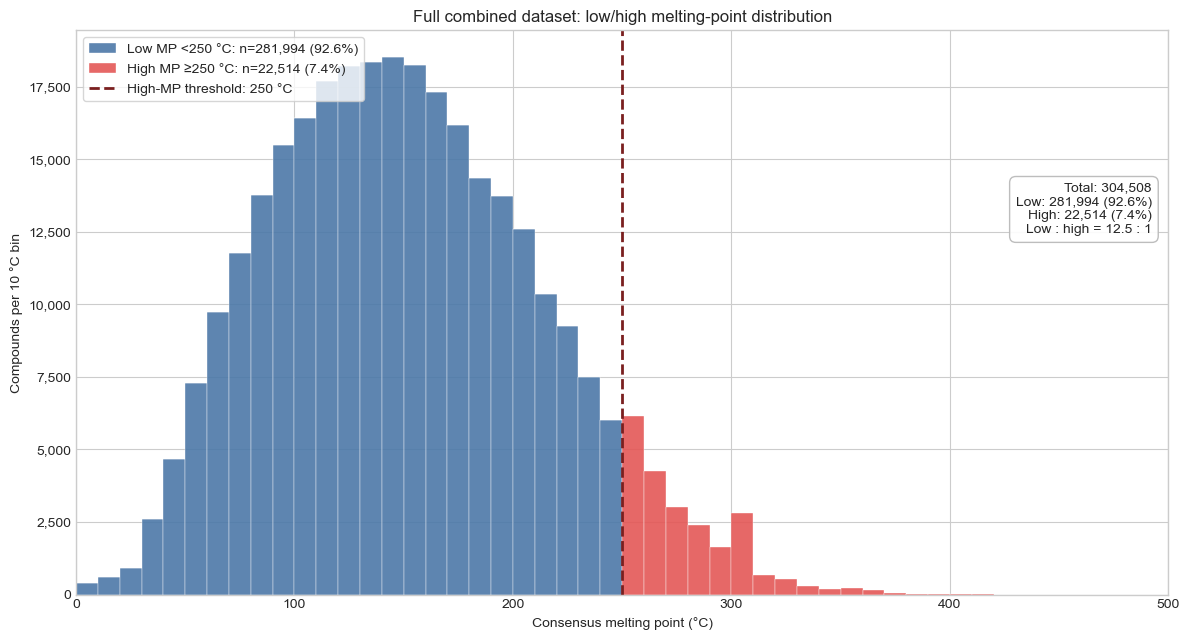

In [3]:
low_mp_values = combined_data.loc[combined_data['MP'].lt(HIGH_THRESHOLD), 'MP']
high_mp_values = combined_data.loc[combined_data['MP'].ge(HIGH_THRESHOLD), 'MP']
low_count, high_count = len(low_mp_values), len(high_mp_values)
total_count = low_count + high_count
low_percent = 100 * low_count / total_count
high_percent = 100 * high_count / total_count
imbalance_ratio = low_count / high_count if high_count else np.inf

bins = np.arange(MP_MIN, MP_MAX + 10, 10)
fig, ax = plt.subplots(figsize=(12, 6.5))
ax.hist(
    [low_mp_values, high_mp_values], bins=bins, stacked=True,
    color=[CLASS_COLORS['Low (<250 °C)'], CLASS_COLORS['High (≥250 °C)']],
    alpha=0.9, edgecolor='white', linewidth=0.3,
    label=[
        f'Low MP <250 °C: n={low_count:,} ({low_percent:.1f}%)',
        f'High MP ≥250 °C: n={high_count:,} ({high_percent:.1f}%)',
    ],
)
ax.axvline(
    HIGH_THRESHOLD, color='#7A1F1F', linestyle='--', linewidth=2,
    label='High-MP threshold: 250 °C',
)
ax.text(
    0.985, 0.73,
    f'Total: {total_count:,}\n'
    f'Low: {low_count:,} ({low_percent:.1f}%)\n'
    f'High: {high_count:,} ({high_percent:.1f}%)\n'
    f'Low : high = {imbalance_ratio:.1f} : 1',
    transform=ax.transAxes, ha='right', va='top', fontsize=10,
    bbox=dict(boxstyle='round,pad=.45', facecolor='white', alpha=.92, edgecolor='#B8B8B8'),
)
ax.set(
    xlim=(MP_MIN, MP_MAX), xlabel='Consensus melting point (°C)',
    ylabel='Compounds per 10 °C bin',
    title='Full combined dataset: low/high melting-point distribution',
)
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax.legend(loc='upper left', frameon=True)
fig.tight_layout()
plt.show()

## Rebuild cleaned source-level observations

This reconstruction is used only for source distributions and overlap. It preserves the source-specific MP values rather than replacing them with the final cross-source consensus.

In [4]:
NUMBER = r'[+-]?(?:\d+(?:\.\d*)?|\.\d+)'
STRICT_RANGE = re.compile(rf'^\s*({NUMBER})\s*[-–]\s*({NUMBER})\s*$')
CHEMXPLORE_NUMBER = re.compile(rf'^\s*({NUMBER})(?:\(\d+\))?\s*$')

HALOGEN_ATOMIC_NUMBERS = {9, 17, 35, 53, 85, 117}
METAL_SYMBOLS = {
    'Li', 'Be', 'Na', 'Mg', 'Al', 'K', 'Ca', 'Sc', 'Ti', 'V', 'Cr', 'Mn', 'Fe',
    'Co', 'Ni', 'Cu', 'Zn', 'Ga', 'Rb', 'Sr', 'Y', 'Zr', 'Nb', 'Mo', 'Tc', 'Ru',
    'Rh', 'Pd', 'Ag', 'Cd', 'In', 'Sn', 'Cs', 'Ba', 'La', 'Ce', 'Pr', 'Nd', 'Pm',
    'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu', 'Hf', 'Ta', 'W',
    'Re', 'Os', 'Ir', 'Pt', 'Au', 'Hg', 'Tl', 'Pb', 'Bi', 'Po', 'Fr', 'Ra', 'Ac',
    'Th', 'Pa', 'U', 'Np', 'Pu', 'Am', 'Cm', 'Bk', 'Cf', 'Es', 'Fm', 'Md', 'No',
    'Lr', 'Rf', 'Db', 'Sg', 'Bh', 'Hs', 'Mt', 'Ds', 'Rg', 'Cn', 'Nh', 'Fl', 'Mc', 'Lv'
}
periodic_table = Chem.GetPeriodicTable()
METAL_ATOMIC_NUMBERS = {
    periodic_table.GetAtomicNumber(symbol) for symbol in METAL_SYMBOLS
}

def parse_mp(value, method):
    if pd.isna(value):
        return np.nan, 'missing'
    text = str(value).strip()
    if method == 'chemxplore':
        match = CHEMXPLORE_NUMBER.fullmatch(text)
        return (float(match.group(1)), 'numeric') if match else (
            np.nan, 'censored_or_approximate'
        )
    try:
        return float(text), 'numeric'
    except ValueError:
        if method == 'numeric_or_range':
            match = STRICT_RANGE.fullmatch(text)
            if match:
                low, high = map(float, match.groups())
                return (low + high) / 2.0, 'range_midpoint'
        return np.nan, 'nonnumeric'

def canonicalize_and_screen(smiles):
    try:
        mol = Chem.MolFromSmiles(str(smiles))
        if mol is None:
            return None, False, False, 0, np.nan
        canonical = Chem.MolToSmiles(mol, canonical=True, isomericSmiles=True)
        roundtrip = Chem.MolFromSmiles(canonical)
        if roundtrip is None:
            return None, False, False, 0, np.nan
        canonical = Chem.MolToSmiles(roundtrip, canonical=True, isomericSmiles=True)
        atomic_numbers = {atom.GetAtomicNum() for atom in roundtrip.GetAtoms()}
        return (
            canonical,
            bool(atomic_numbers & HALOGEN_ATOMIC_NUMBERS),
            bool(atomic_numbers & METAL_ATOMIC_NUMBERS),
            len(Chem.GetMolFrags(roundtrip)),
            float(Descriptors.MolWt(roundtrip)),
        )
    except Exception:
        return None, False, False, 0, np.nan

frames, load_audit_rows = [], []
for source, filename, mp_column, method in SPECS:
    path = INPUT_DIR / filename
    raw = (
        pd.read_parquet(path, columns=['SMILES', mp_column])
        if path.suffix.lower() == '.parquet'
        else pd.read_csv(path, usecols=['SMILES', mp_column], dtype={mp_column: 'string'})
    )
    parsed = raw[mp_column].map(lambda value: parse_mp(value, method))
    frame = pd.DataFrame({
        'Original_SMILES': raw['SMILES'].astype('string'),
        'MP_raw': raw[mp_column].astype('string'),
        'MP_reported': parsed.map(lambda result: result[0]),
        'Parse_status': parsed.map(lambda result: result[1]),
        'Source': np.int8(source),
        'Source_file': filename,
    })
    usable = frame['Original_SMILES'].notna() & frame['MP_reported'].notna()
    load_audit_rows.append({
        'Source': source, 'Source_name': NAMES[source], 'Source_file': filename,
        'Input_rows': len(frame), 'Usable_MP_rows': int(usable.sum()),
        'Excluded_MP_rows': int((~usable).sum()),
        'PATENTS_range_midpoints': int(frame['Parse_status'].eq('range_midpoint').sum()),
    })
    frames.append(frame.loc[usable])

observations = pd.concat(frames, ignore_index=True)
display(pd.DataFrame(load_audit_rows))

unique_raw_smiles = observations['Original_SMILES'].drop_duplicates().tolist()
structure_lookup = pd.DataFrame(
    [canonicalize_and_screen(smiles) for smiles in unique_raw_smiles],
    columns=['SMILES', 'ContainsHalogen', 'ContainsMetal', 'NumFragments', 'MW'],
)
structure_lookup.insert(0, 'Original_SMILES', unique_raw_smiles)
observations = observations.merge(
    structure_lookup, on='Original_SMILES', how='left', validate='many_to_one'
)

invalid_structure = observations['SMILES'].isna()
contains_metal = observations['ContainsMetal'].fillna(False)
multiple_components = observations['NumFragments'].fillna(0).ne(1)
at_or_above_mw_limit = observations['MW'].ge(MAX_MW).fillna(False)
structure_keep = (
    ~invalid_structure & ~contains_metal & ~multiple_components & ~at_or_above_mw_limit
)
structure_audit = pd.DataFrame({
    'Screen': [
        'Invalid/non-round-trippable SMILES',
        'Contains metal (not mutually exclusive)',
        'Multiple components (not mutually exclusive)',
        'MW ≥ 1000 Da (not mutually exclusive)',
        'Structure-screened observations retained',
    ],
    'Count': [
        int(invalid_structure.sum()), int(contains_metal.sum()),
        int(multiple_components.sum()), int(at_or_above_mw_limit.sum()),
        int(structure_keep.sum()),
    ],
})
display(structure_audit)

observations = observations.loc[structure_keep].copy()
observations['Source'] = observations['Source'].astype('int8')
rows_before_deduplication = len(observations)
observations = observations.drop_duplicates(
    ['SMILES', 'MP_reported', 'Source', 'Source_file']
).reset_index(drop=True)

source_compounds = (
    observations.groupby(['Source', 'SMILES'], as_index=False)
    .agg(
        MP=('MP_reported', 'median'),
        MW=('MW', 'first'),
        ContainsHalogen=('ContainsHalogen', 'first'),
        N_observations_in_source=('MP_reported', 'size'),
        N_distinct_MP_in_source=('MP_reported', 'nunique'),
    )
)
outside_source_mp_domain = ~source_compounds['MP'].between(
    MP_MIN, MP_MAX, inclusive='both'
)
source_compounds = source_compounds.loc[~outside_source_mp_domain].copy()
source_compounds['Source_name'] = source_compounds['Source'].map(NAMES)
source_compounds['MP_class'] = np.where(
    source_compounds['MP'].ge(HIGH_THRESHOLD),
    'High (≥250 °C)', 'Low (<250 °C)',
)

print(f'Exact observation duplicates removed: '
      f'{rows_before_deduplication - len(observations):,}')
print(f'Source-level compounds removed outside 0–500 °C: '
      f'{int(outside_source_mp_domain.sum()):,}')
print(f'Source-level compound rows retained: {len(source_compounds):,}')
print(f'Canonical compounds represented across all sources: '
      f'{source_compounds["SMILES"].nunique():,}')

within_source_multiplicity = (
    source_compounds.groupby('Source')['N_observations_in_source']
    .apply(lambda values: int(values.gt(1).sum()))
    .rename('Compounds_with_multiple_within_source_observations')
    .to_frame()
)
display(within_source_multiplicity)

,Source,Source_name,Source_file,Input_rows,Usable_MP_rows,Excluded_MP_rows,PATENTS_range_midpoints
0,1,1 — ChemXplore,1_ChemXplore_tmpC_Marimuthu_2025.csv,7646,7051,595,0
1,2,2 — EGNN,2_EGNN_mp_Huang_2025.csv,237406,237406,0,0
2,3,3 — PATENTS,3_PATENTS_ochem_Tetko_2016.parquet,275133,275045,88,59
3,4,4 — Bradley,4_Bradley_Austermeier_2025.csv,19609,19609,0,0


,Screen,Count
0,Invalid/non-round-trippable SMILES,3
1,Contains metal (not mutually exclusive),105
2,Multiple components (not mutually exclusive),928
3,MW ≥ 1000 Da (not mutually exclusive),214
4,Structure-screened observations retained,537935


Exact observation duplicates removed: 0
Source-level compounds removed outside 0–500 °C: 8,170
Source-level compound rows retained: 529,742
Canonical compounds represented across all sources: 304,828


,Compounds_with_multiple_within_source_observations
Source,
1,0
2,0
3,2
4,21


## Source distributions and low/high MP composition

The histograms use identical 10 °C bins and x-axis limits. Their y-axes are independently scaled so the smaller ChemXplore and Bradley distributions remain visible. The normalized ECDF compares distribution shape independently of source size.

,Source_name,Total_compounds,Min_MP,Median_MP,Mean_MP,Max_MP,Low_count,High_count,Low_percent,High_percent
Source,,,,,,,,,,
1,1 — ChemXplore,5117,0.0,99.0,112.79,450.0,4840,277,94.59,5.41
2,2 — EGNN,234744,0.0,147.0,150.41,481.0,220247,14497,93.82,6.18
3,3 — PATENTS,272682,0.0,147.5,152.20,492.5,251633,21049,92.28,7.72
4,4 — Bradley,17199,0.0,120.0,125.99,492.5,16323,876,94.91,5.09


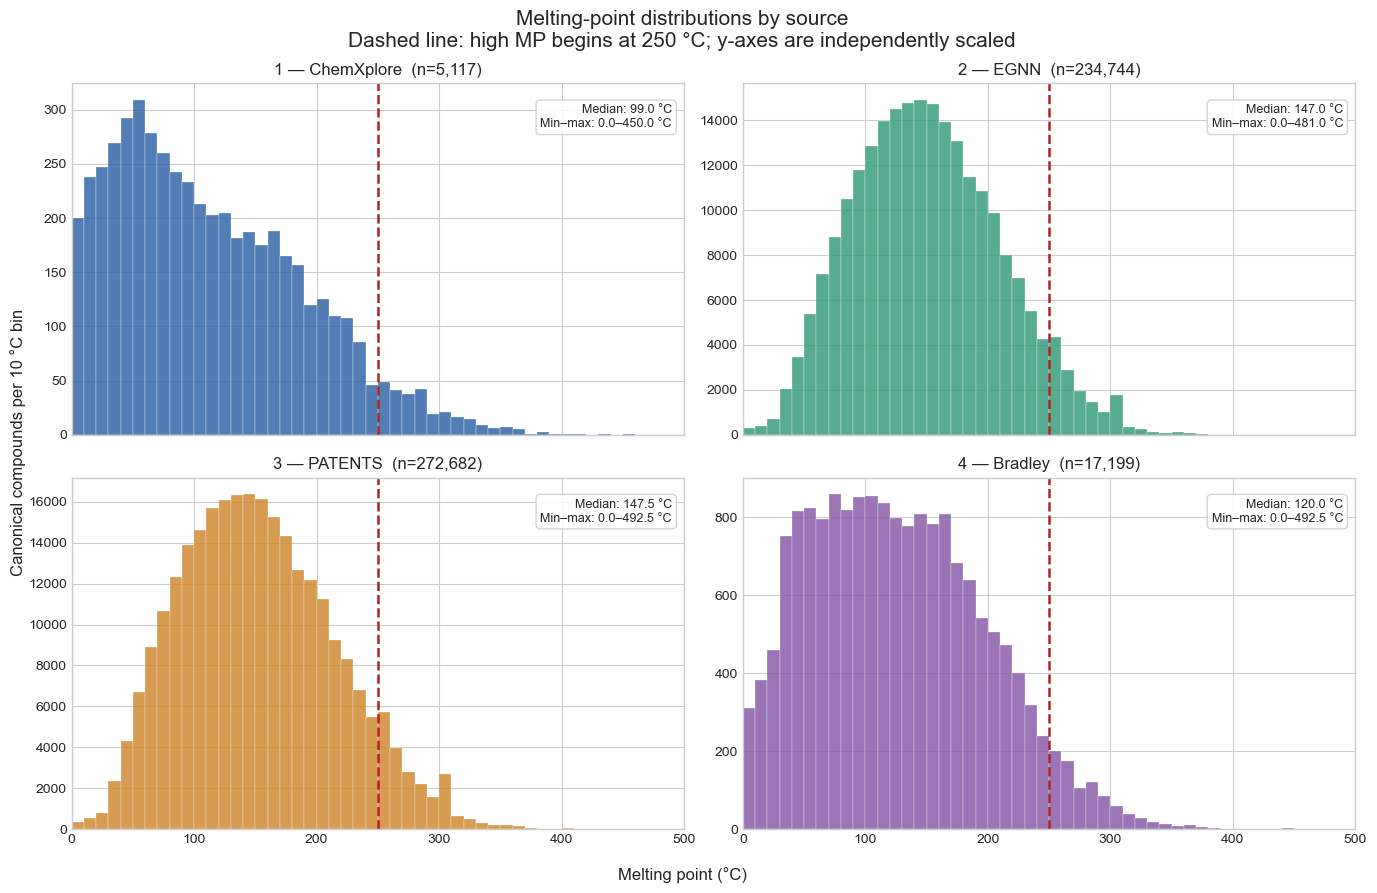

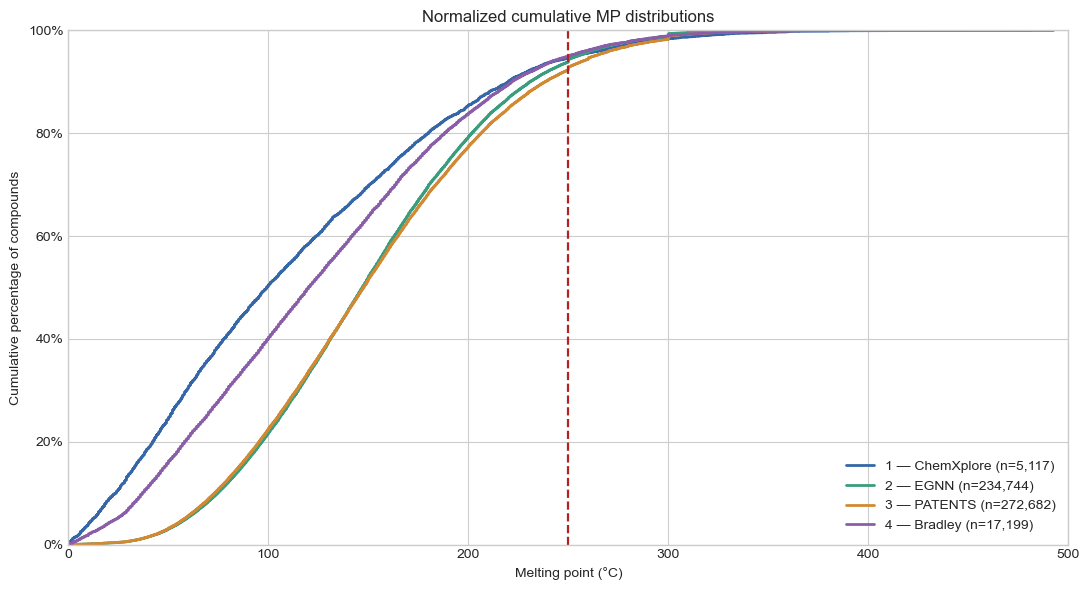

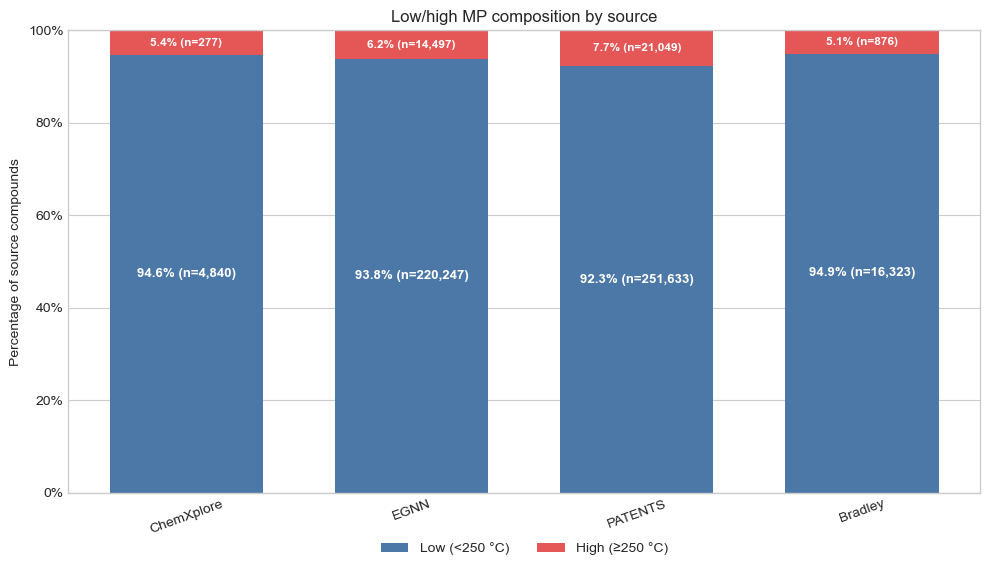

In [5]:
classes = list(CLASS_COLORS)
class_counts = (
    source_compounds.groupby(['Source', 'MP_class'], observed=True).size()
    .unstack(fill_value=0).reindex(index=ORDER, columns=classes, fill_value=0)
)
stats = (
    source_compounds.groupby('Source')
    .agg(
        Total_compounds=('SMILES', 'nunique'), Min_MP=('MP', 'min'),
        Median_MP=('MP', 'median'), Mean_MP=('MP', 'mean'), Max_MP=('MP', 'max'),
    ).reindex(ORDER)
)
summary = stats.join(class_counts.rename(columns={
    classes[0]: 'Low_count', classes[1]: 'High_count',
}))
summary['Low_percent'] = 100 * summary['Low_count'] / summary['Total_compounds']
summary['High_percent'] = 100 * summary['High_count'] / summary['Total_compounds']
summary.insert(0, 'Source_name', [NAMES[source] for source in summary.index])
display(summary.round(2))

bins = np.arange(MP_MIN, MP_MAX + 10, 10)
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=False)
for source, ax in zip(ORDER, axes.flat):
    values = source_compounds.loc[source_compounds['Source'].eq(source), 'MP']
    ax.hist(
        values, bins=bins, color=COLORS[source], alpha=0.85,
        edgecolor='white', linewidth=0.25,
    )
    ax.axvline(HIGH_THRESHOLD, color='#B22222', linestyle='--', linewidth=1.8)
    ax.set_title(f'{NAMES[source]}  (n={len(values):,})')
    ax.text(
        0.98, 0.94,
        f'Median: {values.median():.1f} °C\n'
        f'Min–max: {values.min():.1f}–{values.max():.1f} °C',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=.35', facecolor='white', alpha=.85, edgecolor='#CCC'),
    )
    ax.set_xlim(MP_MIN, MP_MAX)
fig.supxlabel('Melting point (°C)')
fig.supylabel('Canonical compounds per 10 °C bin')
fig.suptitle(
    'Melting-point distributions by source\n'
    'Dashed line: high MP begins at 250 °C; y-axes are independently scaled',
    fontsize=15,
)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 6))
for source in ORDER:
    values = np.sort(
        source_compounds.loc[source_compounds['Source'].eq(source), 'MP'].to_numpy()
    )
    ax.step(
        values, np.arange(1, len(values) + 1) / len(values), where='post',
        label=f'{NAMES[source]} (n={len(values):,})', color=COLORS[source], linewidth=2,
    )
ax.axvline(HIGH_THRESHOLD, color='#B22222', linestyle='--', linewidth=1.6)
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set(
    xlim=(MP_MIN, MP_MAX), ylim=(0, 1), xlabel='Melting point (°C)',
    ylabel='Cumulative percentage of compounds',
    title='Normalized cumulative MP distributions',
)
ax.legend(loc='lower right')
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(ORDER))
percentages = class_counts.div(class_counts.sum(axis=1), axis=0) * 100
bottom = np.zeros(len(ORDER))
for label in classes:
    values = percentages[label].to_numpy()
    counts = class_counts[label].to_numpy()
    bars = ax.bar(
        x, values, bottom=bottom, label=label,
        color=CLASS_COLORS[label], width=0.68,
    )
    for rectangle, value, count, base in zip(bars, values, counts, bottom):
        label_size = 9.5 if label == 'Low (<250 °C)' else 8.5
        ax.text(
            rectangle.get_x() + rectangle.get_width() / 2, base + value / 2,
            f'{value:.1f}% (n={count:,})', ha='center', va='center',
            color='white', fontweight='bold', fontsize=label_size,
        )
    bottom += values
ax.set(
    title='Low/high MP composition by source',
    ylabel='Percentage of source compounds', ylim=(0, 100),
)
ax.yaxis.set_major_formatter(PercentFormatter())
ax.set_xticks(x, [NAMES[source].split(' — ')[1] for source in ORDER], rotation=20)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=2, frameon=False)
fig.tight_layout()
fig.subplots_adjust(bottom=0.17)
plt.show()

## Structural overlap and MP agreement

A shared structure has the same canonical isomeric SMILES in multiple source labels, regardless of MP. An exact MP match additionally has numerically identical source-level median MPs; formatting such as `100` versus `100.0` does not create a difference.

The UpSet-style bars show mutually exclusive source intersections. The compact pairwise table is retained because the intersection plot does not indicate whether shared structures also have matching MP values.

,Combination,Compounds,N_sources
0,2 & 3,194015,2
1,3,63932,1
2,2,28320,1
3,2 & 3 & 4,7853,3
4,1 & 2 & 3 & 4,3017,4
5,3 & 4,2881,2
6,4,1934,1
7,2 & 4,776,2
8,1,637,1
9,1 & 3 & 4,559,3


Compounds represented in more than one source: 210,005


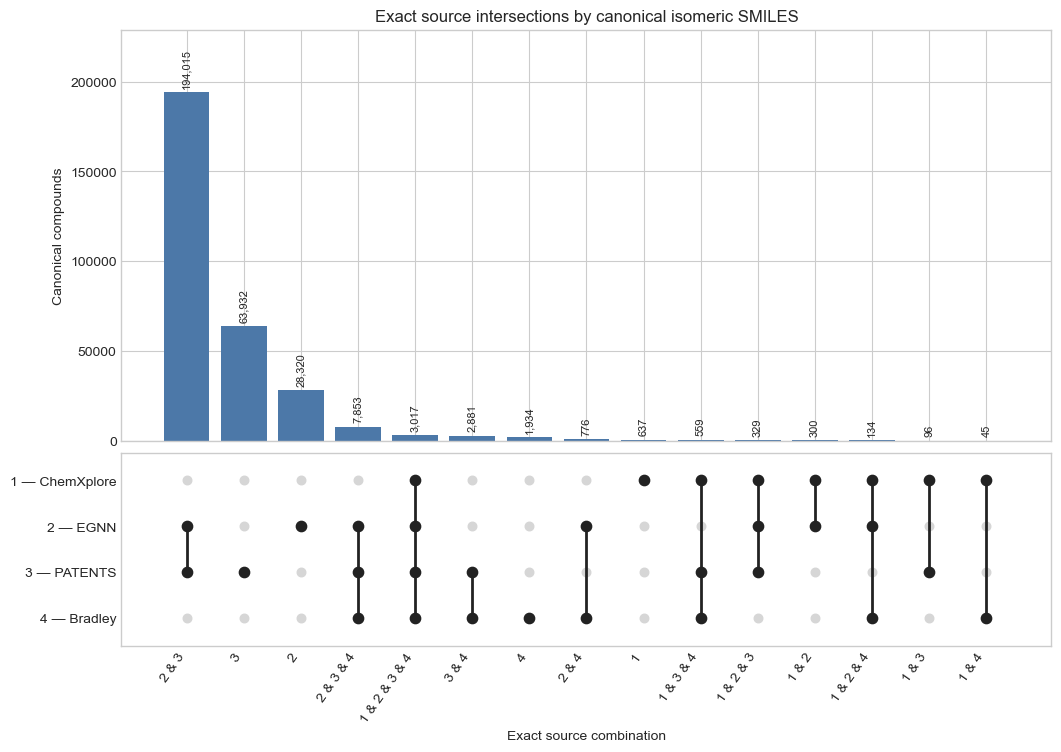

,Source_pair,Shared_SMILES,Exact_MP_matches,Exact_percent,Within_1_C,Within_5_C,Within_10_C,Median_absolute_difference_C,Mean_absolute_difference_C
0,1 & 2,3780,1295,34.26,2487,3495,3640,0.50,2.27
1,1 & 3,4001,1214,30.34,2559,3680,3837,0.55,2.75
2,1 & 4,3755,1259,33.53,2358,3482,3633,0.70,2.17
3,2 & 3,205214,202334,98.60,204171,204830,204991,0.00,0.06
4,2 & 4,11780,9652,81.94,11045,11615,11685,0.00,0.45
5,3 & 4,14310,10066,70.34,12897,13905,14078,0.00,1.10


In [6]:
presence = source_compounds[['SMILES', 'Source']].drop_duplicates()
memberships = presence.groupby('SMILES')['Source'].agg(
    lambda values: tuple(sorted(set(map(int, values))))
)
intersections = (
    memberships.value_counts().rename_axis('Sources').reset_index(name='Compounds')
)
intersections['Combination'] = intersections['Sources'].map(
    lambda values: ' & '.join(map(str, values))
)
intersections['N_sources'] = intersections['Sources'].map(len)
intersections = intersections.sort_values(
    ['Compounds', 'N_sources', 'Combination'],
    ascending=[False, False, True], kind='stable',
).reset_index(drop=True)
display(intersections[['Combination', 'Compounds', 'N_sources']])
print(f'Compounds represented in more than one source: '
      f'{int(memberships.map(len).gt(1).sum()):,}')

x = np.arange(len(intersections))
fig = plt.figure(figsize=(max(12, 0.75 * len(x)), 8))
grid = fig.add_gridspec(2, 1, height_ratios=[3.2, 1.5], hspace=0.04)
top = fig.add_subplot(grid[0])
matrix = fig.add_subplot(grid[1], sharex=top)
bars = top.bar(x, intersections['Compounds'], color='#4C78A8')
top.bar_label(
    bars, labels=[f'{value:,}' for value in intersections['Compounds']],
    padding=3, fontsize=8, rotation=90,
)
top.set_ylabel('Canonical compounds')
top.set_title('Exact source intersections by canonical isomeric SMILES')
top.tick_params(axis='x', labelbottom=False)
top.margins(y=0.18)
for column, sources in enumerate(intersections['Sources']):
    rows = [ORDER.index(source) for source in sources]
    matrix.scatter([column] * len(ORDER), range(len(ORDER)), s=38, color='#D6D6D6', zorder=1)
    matrix.scatter([column] * len(rows), rows, s=55, color='#222', zorder=3)
    if len(rows) > 1:
        matrix.plot([column, column], [min(rows), max(rows)], color='#222', linewidth=2, zorder=2)
matrix.set_yticks(range(len(ORDER)), [NAMES[source] for source in ORDER])
matrix.set_xticks(x, intersections['Combination'], rotation=55, ha='right')
matrix.set_xlabel('Exact source combination')
matrix.set_ylim(-0.6, len(ORDER) - 0.4)
matrix.invert_yaxis()
matrix.grid(False)
plt.show()

source_tables = {
    source: source_compounds.loc[
        source_compounds['Source'].eq(source), ['SMILES', 'MP']
    ].rename(columns={'MP': f'MP_{source}'})
    for source in ORDER
}
agreement_rows = []
for source_a, source_b in combinations(ORDER, 2):
    paired = source_tables[source_a].merge(
        source_tables[source_b], on='SMILES', validate='one_to_one'
    )
    absolute_difference = (paired[f'MP_{source_a}'] - paired[f'MP_{source_b}']).abs()
    exact_match = np.isclose(absolute_difference, 0, rtol=0, atol=1e-12)
    agreement_rows.append({
        'Source_pair': f'{source_a} & {source_b}',
        'Shared_SMILES': len(absolute_difference),
        'Exact_MP_matches': int(exact_match.sum()),
        'Exact_percent': 100 * exact_match.mean() if len(absolute_difference) else np.nan,
        'Within_1_C': int(absolute_difference.le(1).sum()),
        'Within_5_C': int(absolute_difference.le(5).sum()),
        'Within_10_C': int(absolute_difference.le(10).sum()),
        'Median_absolute_difference_C': absolute_difference.median(),
        'Mean_absolute_difference_C': absolute_difference.mean(),
    })
pairwise_agreement = pd.DataFrame(agreement_rows)
display(pairwise_agreement.round(2))

## Extension point for additional analyses

Future analyses can be added below without changing the source-preparation cells above. Suitable additions include MP–MW relationships, consensus-quality diagnostics, scaffold diversity, descriptor distributions, and train/validation/test split diagnostics.

For modeling analyses, establish and save the molecular split before fitting imputation, scaling, feature selection, dimensionality reduction, or learned representations. Fit those steps on training data only.